## B. Data Cleaning
Goal: get familiar with the strengths and weaknesses of the data set and prepare it for in-depth analysis. 

We will start by looking at the missing values by solving the following tasks: 
- Are there any duplicated products in the data ? Can you remove them ? What is the shape of the remaining data ? 

The data set contains a lot of missing values:
- Create a table that shows the number and percentage of missing values for all columns (sorted from largest to smallest). 
- Try installing and testing out the missingno library to help visualize where the missing values are in the data frame. 
- Use the 4 lists created in the previous task to create 4 line plots or bar charts that show the percentage of missing values in each list. 

Now that you know the extent of missing values in the data, it is time to address them. Your goal is to keep as much data as possible in your data frame. At each step report how many samples and features remain. 
- remove rows and columns that are completely empty
- Start with the list of unit columns, and check what information they hold. Fill up missing values by using the most frequent value as a proxy for the missing value. 
- As a second strategy fill up the missing values of a column using other columns that hold similar information. Apply this approach on the product_name_en column. Find columns that hold similar information and use them to replace the missing values in product_name_en. Report the number of rows that you filled up. 
- As a third strategy, let’s fill up missing values based on common knowledge. Take the column named iron_per_hundred which has about 30% missing values. One possible explanation for its missing values could be that those products are iron-free (like ice cream). Based on this assumption address the missing values for iron_per_hundred.
- Another strategy for text-based columns is to indicate that some of the fields are missing. For instance, the column ingredients_en has about 10% of missing values. Let’s replace them with the term ingredient_missing.
- Finally, let’s assume that you want to build up your data analysis pipeline based on at least 20,000 rows of non-missing data. This amounts to about 5% of the data set. Your task is to drop the columns that have more than 95% of missing values. What is the shape of the remaining data?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Import the data as a pandas DataFrame into your notebook
df = pd.DataFrame(pd.read_pickle("data_385k.pkl", compression="zip"))
df.head(5)

,alcohol_by_volume,barcode,calcium_per_hundred,calcium_unit,carbohydrates_per_hundred,carbohydrates_per_portion,carbohydrates_unit,cholesterol_per_hundred,cholesterol_unit,copper_cu_per_hundred,...,vitamin_b5_panthothenic_acid_per_hundred,vitamin_b5_panthothenic_acid_unit,vitamin_b6_pyridoxin_per_hundred,vitamin_b6_pyridoxin_unit,vitamin_c_ascorbic_acid_per_hundred,vitamin_c_ascorbic_acid_unit,vitamin_d_d2_d3_international_units_per_hundred,vitamin_d_d2_d3_international_units_unit,zinc_per_hundred,zinc_unit
0,0.0,8001772000030,NaN,NaN,75.00,37.50,g,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,7610809001066,NaN,NaN,1.50,1.13,g,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,8002530159021,NaN,NaN,52.68,NaN,g,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,3033715065788,NaN,NaN,70.40,11.97,g,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,7610848492740,NaN,NaN,37.00,7.40,g,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Are there any duplicated data in the data frame?
print("there are", df.duplicated().sum(), "duplicates in the data frame")

there are 10500 duplicates in the data frame


In [5]:
# Remove all duplicated rows:
print("old data frame shape:", df.shape)

df = df.drop_duplicates()

# Shape of the remaining data:
print("new data frame shape:", df.shape)

old data frame shape: (385384, 99)
new data frame shape: (374884, 99)


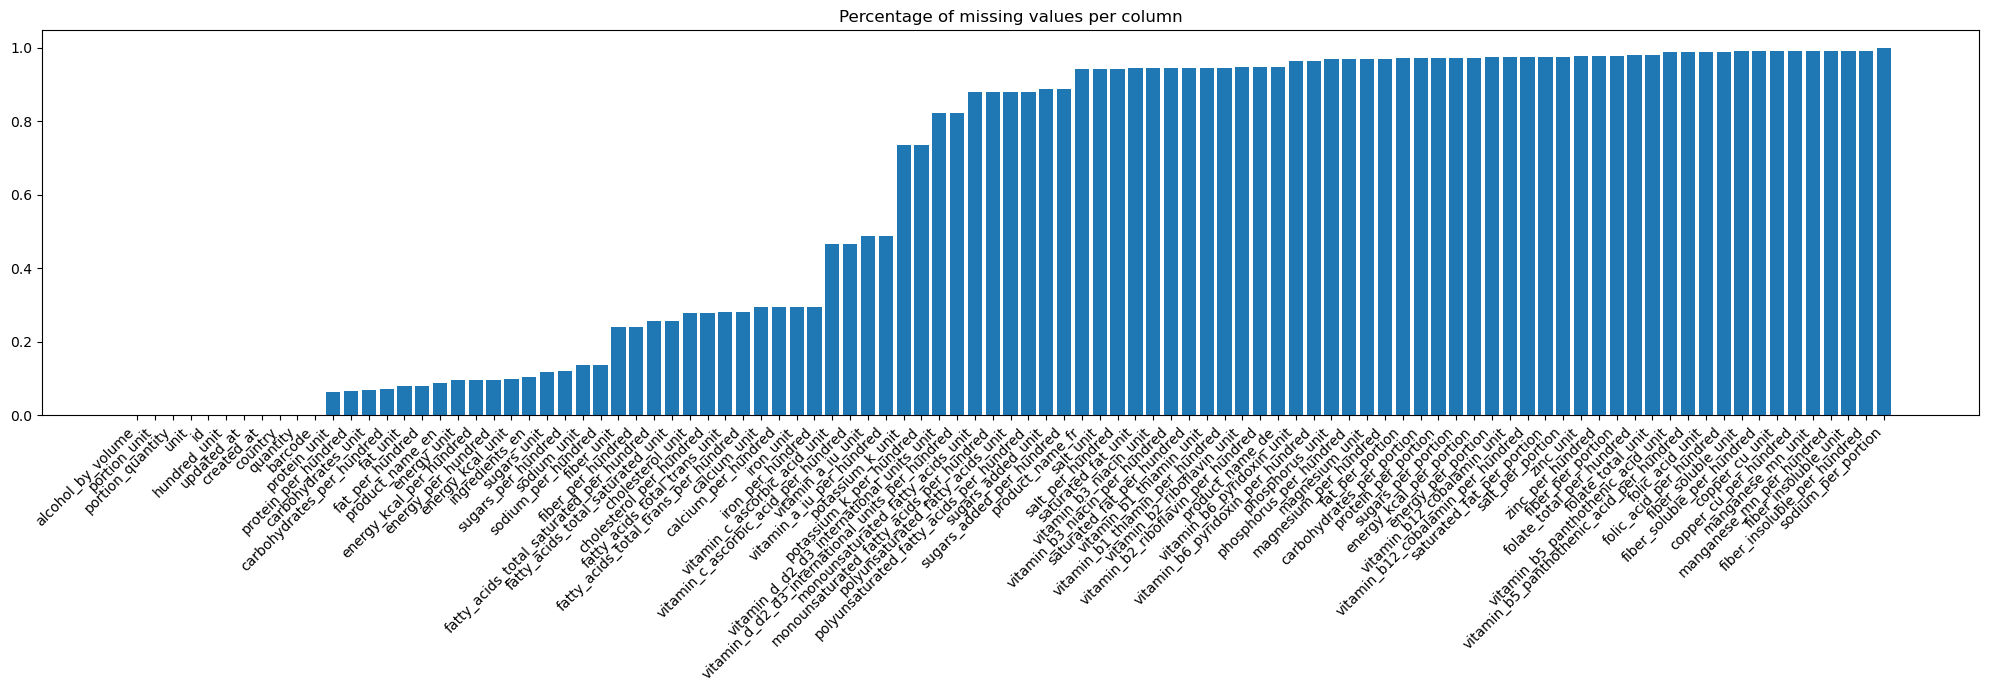

In [42]:
# Are there any missing values in columns ?
# Print the number of missing values and the precentage of missing values for each column
missing = pd.DataFrame(df.isna().sum(), columns=["n_missing"])
missing["percent_missing"] = missing.n_missing / len(df)

# plot the columns sorted according to their percentage of missing values
plt.figure(figsize=(25, 5)) 
plt.bar(x=missing.sort_values("percent_missing").index, height=missing.sort_values("percent_missing").percent_missing)
plt.title("Percentage of missing values per column")
plt.xticks(rotation=45, ha="right")   # or ha="right"
plt.show()

### Comments

We observe that there is a very high percentage of missing values for many of the columns. This is something we will need to adress further on.

In [ ]:
# Try installing and testing out the missingno library to help visualize where the missing values are in the data frame.
import missingno as msno
%matplotlib inline

In [ ]:
msno.matrix(df)

<AxesSubplot:>

Text(0.5, 0.9, 'Percentage of missing values per list')

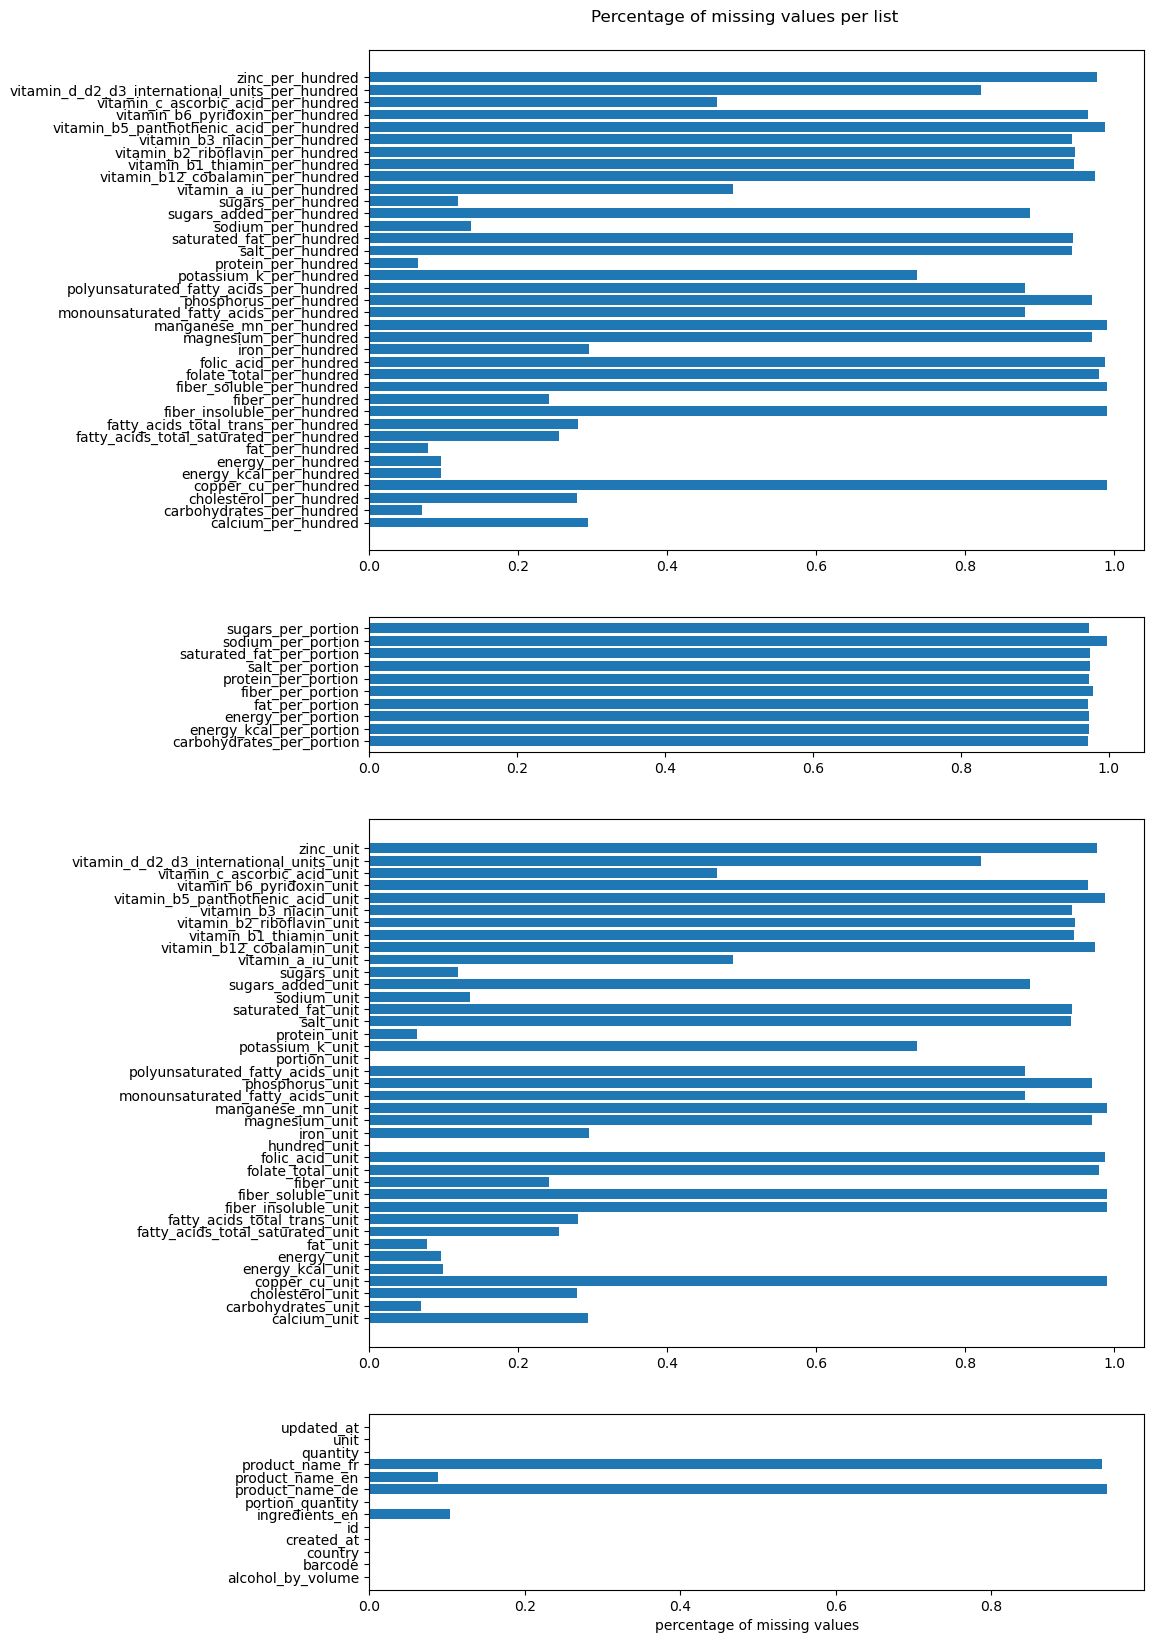

In [ ]:
# Use the 4 lists created in the previous task to create 4 line plots or bar charts that show the percentage of missing values in each list. 

# I'm not sure I understood this task correctly. I will make two different graphs to adress the two ways that I understood the task

# compute the length of each list to allocate the correct size to the subplots:
n0 = len(col_hundred)
n1 = len(col_portion)
n2 = len(col_unit)
n3 = len(col_other)

fig, axes = plt.subplots(4, 1, figsize=(10,20), gridspec_kw={"height_ratios": [n0, n1, n2, n3]})
axes[0].barh(col_hundred, missing.loc[col_hundred, "percent_missing"])
axes[1].barh(col_portion, missing.loc[col_portion, "percent_missing"])
axes[2].barh(col_unit, missing.loc[col_unit, "percent_missing"])
axes[3].barh(col_other, missing.loc[col_other, "percent_missing"])

plt.xlabel("percentage of missing values")
fig.suptitle("Percentage of missing values per list", y=0.9)

Text(0.5, 1.1, 'Percentage of missing values')

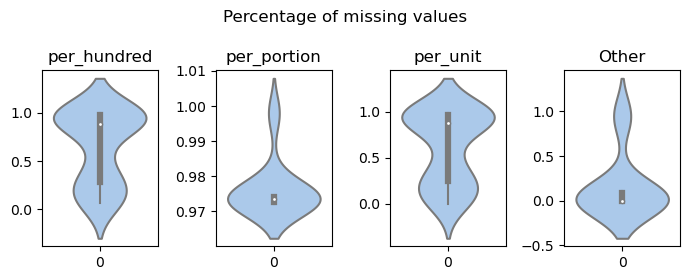

In [ ]:
# Here, I am making a violin plot for each list with the average percentage of missing values

fig, axes = plt.subplots(1, 4, figsize=(7, 2.5))
sns.set_palette("pastel")
sns.violinplot(data=missing.loc[col_hundred, "percent_missing"], ax=axes[0])
sns.violinplot(data=missing.loc[col_portion, "percent_missing"], ax=axes[1])
sns.violinplot(data=missing.loc[col_unit, "percent_missing"], ax=axes[2])
sns.violinplot(data=missing.loc[col_other, "percent_missing"], ax=axes[3])
axes[0].set_title("per_hundred")
axes[1].set_title("per_portion")
axes[2].set_title("per_unit")
axes[3].set_title("Other")
plt.tight_layout()
fig.suptitle("Percentage of missing values", y=1.1)

#### Comments

We see that we are dealing with some columns that have a lot of missing values! Especially in the per_hundred and per_unit columns. Interestingly, the distribution seems to be similar for those two columns, we could hypothetize that a lot of columns have information neither in the per_hundred nor in the per_unit row.

In [ ]:
# Now that you know the extent of missing values in the data, it is time to address them. Your goal is to keep as much data as possible in your data frame. At each step report how many samples and features remain. 
# remove rows and columns that are completely empty

print("original data frame shape:", df_clean.shape)

df_clean = df_clean.dropna(axis=0, how="all")
df_clean = df_clean.dropna(axis=1, how="all")

print("new data frame shape:", df_clean.shape)

original data frame shape: (374884, 99)
new data frame shape: (374884, 99)


#### Comments

We see that this approach didn't remove any rows or columns, as we didn't have any row or column that is completely empty. 

In [ ]:
# Start with the list of unit columns, and check what information they hold. Fill up missing values by using the most frequent value as a proxy for the missing value. 

# Get the most frequent value per column
top = df_clean.loc[:, col_unit].describe().loc["top", :]

# fill in the missing values: 
df_clean.loc[:, col_unit] = df_clean.loc[:, col_unit].fillna(top, axis=0)

# Make sure that it worked
print(df_clean.loc[:, col_unit].isna().sum().sum())

0


In [ ]:
# As a second strategy fill up the missing values of a column using other columns that hold similar information. 
# Apply this approach on the product_name_en column. Find columns that hold similar information and use them to replace the missing values in product_name_en. 
# Report the number of rows that you filled up. 

# First calculate the number of rows that are empty:
empty_origin_en = df_clean.product_name_en.isna().sum()
empty_origin_fr = df_clean.product_name_de.isna().sum()
print("originally, there are " , empty_origin_en, " empty rows")

# We could fill the product_name_en by product_name_fr or product_name_de
df_clean.loc[:, "product_name_en"] = df_clean.loc[:, "product_name_en"].fillna(df_clean.loc[:, "product_name_fr"])
empty_fr = df_clean.product_name_en.isna().sum()
print("Using the french column filled up ", empty_origin_en - empty_fr, "rows")

df_clean.loc[:, "product_name_en"] = df_clean.loc[:, "product_name_en"].fillna(df_clean.loc[:, "product_name_de"])
empty_de = df_clean.product_name_en.isna().sum()
print("using the german column filled up ", empty_origin_en - empty_de, "rows")

# We see that this is not a good strategy, since not all rows were filled up. 

# An alternative would be to fill this up using the barcode. 
df_clean.loc[:, "product_name_en"] = df_clean.loc[:, "product_name_en"].fillna(df_clean.loc[:, "barcode"])
empty_barcode = df_clean.product_name_en.isna().sum()
print("using the barcode column filled up ", empty_origin_en - empty_barcode, "rows")

originally, there are  33165  empty rows
Using the french column filled up  11619 rows
using the german column filled up  14299 rows
using the barcode column filled up  33165 rows


In [ ]:
df_clean.head()

,alcohol_by_volume,barcode,calcium_per_hundred,calcium_unit,carbohydrates_per_hundred,carbohydrates_per_portion,carbohydrates_unit,cholesterol_per_hundred,cholesterol_unit,copper_cu_per_hundred,...,vitamin_b5_panthothenic_acid_per_hundred,vitamin_b5_panthothenic_acid_unit,vitamin_b6_pyridoxin_per_hundred,vitamin_b6_pyridoxin_unit,vitamin_c_ascorbic_acid_per_hundred,vitamin_c_ascorbic_acid_unit,vitamin_d_d2_d3_international_units_per_hundred,vitamin_d_d2_d3_international_units_unit,zinc_per_hundred,zinc_unit
0,0.0,8001772000030,NaN,mg,75.00,37.50,g,NaN,mg,NaN,...,NaN,mg,NaN,mg,NaN,mg,NaN,IU,NaN,mg
1,0.0,7610809001066,NaN,mg,1.50,1.13,g,NaN,mg,NaN,...,NaN,mg,NaN,mg,NaN,mg,NaN,IU,NaN,mg
2,0.0,8002530159021,NaN,mg,52.68,NaN,g,NaN,mg,NaN,...,NaN,mg,NaN,mg,NaN,mg,NaN,IU,NaN,mg
3,0.0,3033715065788,NaN,mg,70.40,11.97,g,NaN,mg,NaN,...,NaN,mg,NaN,mg,NaN,mg,NaN,IU,NaN,mg
4,0.0,7610848492740,NaN,mg,37.00,7.40,g,NaN,mg,NaN,...,NaN,mg,NaN,mg,NaN,mg,NaN,IU,NaN,mg


In [ ]:
# As a third strategy, let’s fill up missing values based on common knowledge. 
# Take the column named iron_per_hundred which has about 30% missing values. 
# One possible explanation for its missing values could be that those products are iron-free (like ice cream). 
# Based on this assumption address the missing values for iron_per_hundred.

# Let's replace all missing values with 0 

print("there are originally", df_clean.iron_per_hundred.isna().sum(), "missing values")

df_clean.iron_per_hundred = df_clean.iron_per_hundred.fillna(value=0)

print("there are now", df_clean.iron_per_hundred.isna().sum(), "missing values")


there are originally 110495 missing values
there are now 0 missing values


In [ ]:
# Another strategy for text-based columns is to indicate that some of the fields are missing. 
# For instance, the column ingredients_en has about 10% of missing values. Let’s replace them with the term ingredient_missing.

print("there are originally", df_clean.ingredients_en.isna().sum(), "missing values")

df_clean.ingredients_en = df_clean.ingredients_en.fillna(value="ingredient_missing")

print("there are now", df_clean.iron_per_hundred.isna().sum(), "missing values")


there are originally 38958 missing values
there are now 0 missing values


In [ ]:
# Finally, let’s assume that you want to build up your data analysis pipeline based on at least 20,000 rows of non-missing data. 
# This amounts to about 5% of the data set. Your task is to drop the columns that have more than 95% of missing values. 
# What is the shape of the remaining data?

print("original shape:", df_clean.shape)

# Number of missing values that correspond to 95% of rows
threshold_95 = round(0.05*len(df_clean))

#drop those columns
df_clean = df_clean.dropna(axis=1, thresh=threshold_95)

print("new shape:", df_clean.shape)

original shape: (374884, 99)
new shape: (374884, 77)
